# Edge IIoT - Binary Classification


In [192]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [193]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import DATASETS

# Seleccionamos el dataset a analizar
dataset_name = "edge_iiot"
config = DATASETS[dataset_name]

print("\n--- Dataset Information ---")
print(f"Name: {dataset_name.upper()}")
print(f"Path: {config['processed_path']}\n")

filename = "ML-EdgeIIoT-dataset"

csv_path = config['processed_path'] / f"{filename}.pkl"
print(f"CSV Path: {csv_path}\n")

print("Loading dataset... (This may take a while)")
df = pd.read_pickle(csv_path)

print(f"\nDataset loaded with shape: {df.shape}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

--- Dataset Information ---
Name: EDGE_IIOT
Path: /home/uo294319/ML-NIDS-IIoT/data/processed/edge_iiot

CSV Path: /home/uo294319/ML-NIDS-IIoT/data/processed/edge_iiot/ML-EdgeIIoT-dataset.pkl

Loading dataset... (This may take a while)

Dataset loaded with shape: (140162, 59)


## 1. Pre-processing

In [194]:
df_naive = df.select_dtypes(include=['number'])

target = 'Attack_label'
X = df_naive.drop(columns=[target])
y = df_naive[target]

Y_str = df['Attack_type'] # Used to stratify later

In [195]:
categorical_cols = X.select_dtypes(include=['str', 'object', 'category']).columns
print(f"Check for categorical columns: {list(categorical_cols)}", "\t(Should only include 'Attack_type')")
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

Check for categorical columns: [] 	(Should only include 'Attack_type')


In [196]:
X.columns

Index(['icmp.seq_le', 'http.content_length', 'http.response', 'http.tls_port',
       'tcp.ack', 'tcp.len', 'tcp.seq', 'udp.stream', 'udp.time_delta',
       'dns.retransmission', 'dns.retransmit_request',
       'dns.retransmit_request_in', 'mqtt.conack.flags',
       'mqtt.conflag.cleansess', 'mqtt.len', 'mqtt.msgtype', 'mbtcp.len',
       'mbtcp.trans_id', 'mbtcp.unit_id', 'frame.time.order',
       'frame.time.delta', 'ip.src_category_Malformed',
       'ip.src_category_Private', 'ip.src_category_Public',
       'ip.src_category_Reserved', 'ip.dst_category_Malformed',
       'ip.dst_category_Private', 'ip.dst_category_Public',
       'ip.dst_category_Reserved', 'arp.opcode_request', 'arp.opcode_reply',
       'http.request.method_get', 'http.request.method_post',
       'http.request.method_options', 'http.request.method_trace',
       'tcp.nullchecksum', 'tcp.flag.res', 'tcp.flag.ns', 'tcp.flag.cwr',
       'tcp.flag.ece', 'tcp.flag.urg', 'tcp.flag.ack', 'tcp.flag.psh',
       'tc

In [197]:
print(f"\nFinal feature set shape after encoding: {X.shape}")
print(f"NaN values in target variable: {y.isna().sum()}")
print(f"NaN values in features: {X.isna().sum().sum()}")


Final feature set shape after encoding: (140162, 50)
NaN values in target variable: 0
NaN values in features: 0


In [198]:
X_train, X_test, y_train, y_test, Y_str_train, Y_str_test = train_test_split(
    X, y, Y_str, test_size=0.2, random_state=42, stratify=Y_str
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_results = {}

X_train shape: (112129, 50)
X_test shape: (28033, 50)


## 2. Auxiliar Functions

In [199]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
summary_df = pd.DataFrame(columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1_Score', 'AUC'])

In [200]:
from IPython.display import display

def evaluate_model(y_true, y_pred, y_prob, model_name, attack_types=None, tracking_df=None):
    print(f"--- Eval {model_name} ---\n")

    # --- Overall Metrics ---
    print("Classification Report:")
    print(classification_report(y_true, y_pred))
    
    # --- ROC AUC Score ---
    auc_score = roc_auc_score(y_true, y_prob)
    print(f"ROC AUC Score: {auc_score:.4f}\n")
    
    # --- Confusion Matrix ---
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Real')
    plt.xlabel('Predicted')
    plt.show()
    
    # --- Analytics per Attack Type ---
    if attack_types is not None:
        print(f"\n--- Analytics per Attack Type ({model_name}) ---")
        
        y_true_arr = y_true.values if hasattr(y_true, 'values') else y_true
        attack_arr = attack_types.values if hasattr(attack_types, 'values') else attack_types
        
        results_df = pd.DataFrame({
            'True_Label': y_true_arr,
            'Predicted_Label': y_pred,
            'Attack_Type': attack_arr
        })
        
        metrics_list = []
        for attack, group in results_df.groupby('Attack_Type'):
            total = len(group)
            correct = (group['True_Label'] == group['Predicted_Label']).sum()
            accuracy = correct / total
            metrics_list.append({
                'Attack_Type': attack,
                'Total_Samples': total,
                'Correct_Predictions': correct,
                'Detection_Rate (%)': round(accuracy * 100, 2)
            })
            
        metrics_df = pd.DataFrame(metrics_list).sort_values(by='Detection_Rate (%)', ascending=True)
        display(metrics_df)
    
    # --- Tracking Results ---
    if tracking_df is not None:
        new_row = pd.DataFrame({
            'Model': [model_name],
            'Accuracy': [accuracy_score(y_true, y_pred)],
            'Precision': [precision_score(y_true, y_pred, average='weighted')],
            'Recall': [recall_score(y_true, y_pred, average='weighted')],
            'F1_Score': [f1_score(y_true, y_pred, average='weighted')],
            'AUC': [auc_score]
        })
        
        tracking_df = pd.concat([tracking_df, new_row], ignore_index=True)
        return tracking_df

## 3. Naive Implementation

### 3.1. Logistic Regression.

--- Eval Logistic Regression ---

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.68      0.72      4846
           1       0.94      0.95      0.94     23187

    accuracy                           0.91     28033
   macro avg       0.84      0.82      0.83     28033
weighted avg       0.90      0.91      0.90     28033

ROC AUC Score: 0.9677



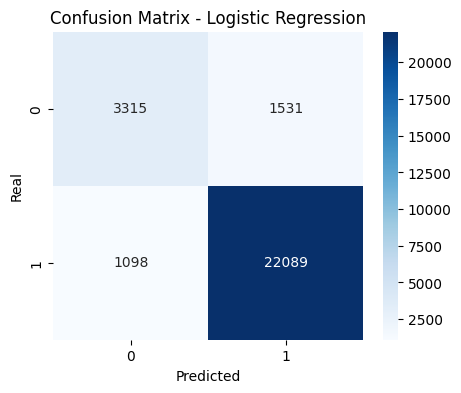


--- Analytics per Attack Type (Logistic Regression) ---


,Attack_Type,Total_Samples,Correct_Predictions,Detection_Rate (%)
4,Fingerprinting,187,25,13.37
8,Ransomware,2039,1211,59.39
5,Normal,4846,3315,68.41
3,DDoS_TCP,2050,1963,95.76
10,Uploading,2052,2035,99.17
2,DDoS_ICMP,2818,2814,99.86
0,Backdoor,1998,1998,100.00
1,DDoS_HTTP,2112,2112,100.00
7,Port_Scanning,1938,1938,100.00
6,Password,1996,1996,100.00


In [201]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

summary_df = evaluate_model(y_test, y_pred_lr, y_prob_lr, "Logistic Regression", attack_types=Y_str_test, tracking_df=summary_df)

## 4. Tree Classifiers


### 4.1. Random Forest Classifier

--- Eval Random Forest ---

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4846
           1       1.00      1.00      1.00     23187

    accuracy                           1.00     28033
   macro avg       1.00      1.00      1.00     28033
weighted avg       1.00      1.00      1.00     28033

ROC AUC Score: 0.9998



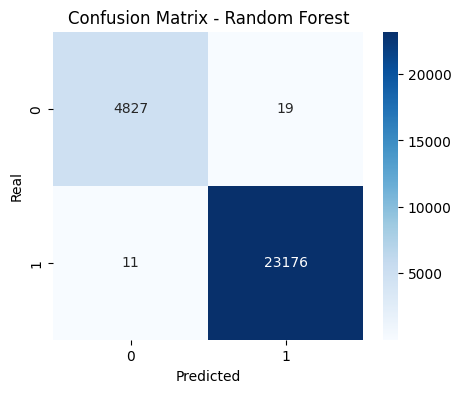


--- Analytics per Attack Type (Random Forest) ---


,Attack_Type,Total_Samples,Correct_Predictions,Detection_Rate (%)
4,Fingerprinting,187,185,98.93
5,Normal,4846,4827,99.61
8,Ransomware,2039,2032,99.66
10,Uploading,2052,2050,99.90
3,DDoS_TCP,2050,2050,100.00
2,DDoS_ICMP,2818,2818,100.00
0,Backdoor,1998,1998,100.00
1,DDoS_HTTP,2112,2112,100.00
7,Port_Scanning,1938,1938,100.00
6,Password,1996,1996,100.00


In [202]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

summary_df = evaluate_model(y_test, y_pred_rf, y_prob_rf, "Random Forest", attack_types=Y_str_test, tracking_df=summary_df)

### 4.2. Extra Trees Classifier

--- Eval Extra Trees ---

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      4846
           1       1.00      1.00      1.00     23187

    accuracy                           1.00     28033
   macro avg       1.00      1.00      1.00     28033
weighted avg       1.00      1.00      1.00     28033

ROC AUC Score: 0.9998



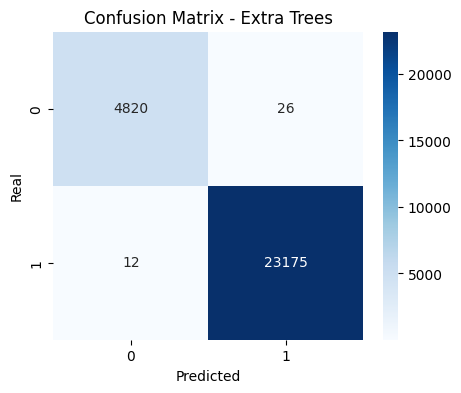


--- Analytics per Attack Type (Extra Trees) ---


,Attack_Type,Total_Samples,Correct_Predictions,Detection_Rate (%)
5,Normal,4846,4820,99.46
4,Fingerprinting,187,186,99.47
8,Ransomware,2039,2032,99.66
10,Uploading,2052,2049,99.85
12,XSS,1924,1923,99.95
3,DDoS_TCP,2050,2050,100.00
0,Backdoor,1998,1998,100.00
1,DDoS_HTTP,2112,2112,100.00
7,Port_Scanning,1938,1938,100.00
6,Password,1996,1996,100.00


In [203]:
from sklearn.ensemble import ExtraTreesClassifier

et_model = ExtraTreesClassifier(
    n_estimators=100, 
    random_state=42,
    n_jobs=-1
)
et_model.fit(X_train, y_train)

y_pred_et = et_model.predict(X_test)
y_prob_et = et_model.predict_proba(X_test)[:, 1]


summary_df = evaluate_model(
    y_true=y_test, 
    y_pred=y_pred_et, 
    y_prob=y_prob_et, 
    model_name="Extra Trees", 
    attack_types=Y_str_test, 
    tracking_df=summary_df
)

### 4.3. Decision Tree Classifier

--- Eval Decision Tree ---

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      4846
           1       1.00      1.00      1.00     23187

    accuracy                           1.00     28033
   macro avg       1.00      1.00      1.00     28033
weighted avg       1.00      1.00      1.00     28033

ROC AUC Score: 0.9963



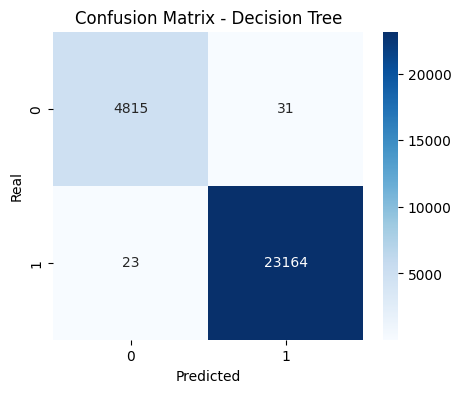


--- Analytics per Attack Type (Decision Tree) ---


,Attack_Type,Total_Samples,Correct_Predictions,Detection_Rate (%)
4,Fingerprinting,187,183,97.86
5,Normal,4846,4815,99.36
8,Ransomware,2039,2030,99.56
10,Uploading,2052,2046,99.71
11,Vulnerability_scanner,2013,2012,99.95
9,SQL_injection,2060,2059,99.95
12,XSS,1924,1923,99.95
2,DDoS_ICMP,2818,2817,99.96
7,Port_Scanning,1938,1938,100.00
6,Password,1996,1996,100.00


In [204]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

summary_df = evaluate_model(
    y_true=y_test, 
    y_pred=y_pred_dt, 
    y_prob=y_prob_dt, 
    model_name="Decision Tree", 
    attack_types=Y_str_test, 
    tracking_df=summary_df
)

## 5. Gradient Boosting

### 5.1. HistGradientBoosting

--- Eval HistGradientBoosting ---

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      4846
           1       1.00      1.00      1.00     23187

    accuracy                           1.00     28033
   macro avg       1.00      1.00      1.00     28033
weighted avg       1.00      1.00      1.00     28033

ROC AUC Score: 1.0000



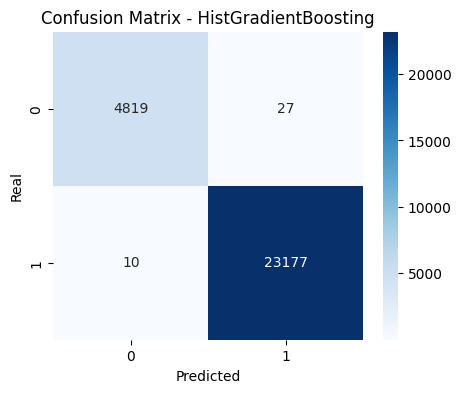


--- Analytics per Attack Type (HistGradientBoosting) ---


,Attack_Type,Total_Samples,Correct_Predictions,Detection_Rate (%)
5,Normal,4846,4819,99.44
8,Ransomware,2039,2034,99.75
12,XSS,1924,1921,99.84
10,Uploading,2052,2050,99.90
3,DDoS_TCP,2050,2050,100.00
0,Backdoor,1998,1998,100.00
2,DDoS_ICMP,2818,2818,100.00
1,DDoS_HTTP,2112,2112,100.00
7,Port_Scanning,1938,1938,100.00
6,Password,1996,1996,100.00


In [205]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb_model = HistGradientBoostingClassifier(random_state=42)
hgb_model.fit(X_train, y_train)

y_pred_hgb = hgb_model.predict(X_test)
y_prob_hgb = hgb_model.predict_proba(X_test)[:, 1]

summary_df = evaluate_model(y_test, y_pred_hgb, y_prob_hgb, "HistGradientBoosting", attack_types=Y_str_test, tracking_df=summary_df)

### 5.2. XGBoost

--- Eval XGBoost ---

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      4846
           1       1.00      1.00      1.00     23187

    accuracy                           1.00     28033
   macro avg       1.00      1.00      1.00     28033
weighted avg       1.00      1.00      1.00     28033

ROC AUC Score: 1.0000



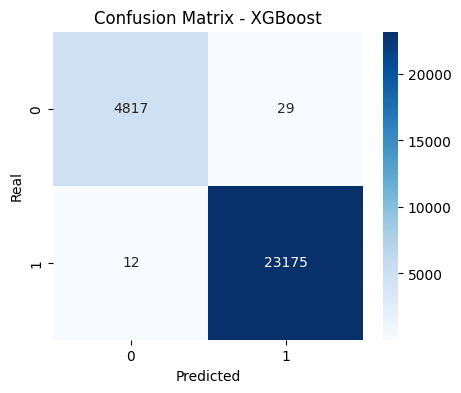


--- Analytics per Attack Type (XGBoost) ---


,Attack_Type,Total_Samples,Correct_Predictions,Detection_Rate (%)
5,Normal,4846,4817,99.40
8,Ransomware,2039,2030,99.56
10,Uploading,2052,2050,99.90
12,XSS,1924,1923,99.95
3,DDoS_TCP,2050,2050,100.00
0,Backdoor,1998,1998,100.00
2,DDoS_ICMP,2818,2818,100.00
1,DDoS_HTTP,2112,2112,100.00
7,Port_Scanning,1938,1938,100.00
6,Password,1996,1996,100.00


In [206]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100, 
    random_state=42, 
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

summary_df = evaluate_model(
    y_true=y_test, 
    y_pred=y_pred_xgb, 
    y_prob=y_prob_xgb, 
    model_name="XGBoost", 
    attack_types=Y_str_test, 
    tracking_df=summary_df
)

### 5.3. LightGBM

[LightGBM] [Info] Number of positive: 92744, number of negative: 19385
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007783 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1623
[LightGBM] [Info] Number of data points in the train set: 112129, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.827119 -> initscore=1.565343
[LightGBM] [Info] Start training from score 1.565343
--- Eval LightGBM ---

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4846
           1       1.00      1.00      1.00     23187

    accuracy                           1.00     28033
   macro avg       1.00      1.00      1.00     28033
weighted avg       1.00      1.00      1.00     28033

ROC AUC Score: 1.0000



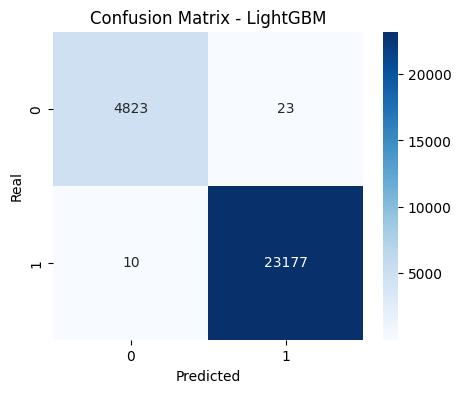


--- Analytics per Attack Type (LightGBM) ---


,Attack_Type,Total_Samples,Correct_Predictions,Detection_Rate (%)
5,Normal,4846,4823,99.53
8,Ransomware,2039,2033,99.71
10,Uploading,2052,2050,99.90
12,XSS,1924,1922,99.90
3,DDoS_TCP,2050,2050,100.00
0,Backdoor,1998,1998,100.00
2,DDoS_ICMP,2818,2818,100.00
1,DDoS_HTTP,2112,2112,100.00
7,Port_Scanning,1938,1938,100.00
6,Password,1996,1996,100.00


In [207]:
from lightgbm import LGBMClassifier


lgbm_model = LGBMClassifier(
    n_estimators=100, 
    random_state=42,
    n_jobs=-1
)
lgbm_model.fit(X_train, y_train)

y_pred_lgbm = lgbm_model.predict(X_test)
y_prob_lgbm = lgbm_model.predict_proba(X_test)[:, 1]


summary_df = evaluate_model(
    y_true=y_test, 
    y_pred=y_pred_lgbm, 
    y_prob=y_prob_lgbm, 
    model_name="LightGBM", 
    attack_types=Y_str_test, 
    tracking_df=summary_df
)

### 5.4. CatBoost

--- Eval CatBoost ---

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4846
           1       1.00      1.00      1.00     23187

    accuracy                           1.00     28033
   macro avg       1.00      1.00      1.00     28033
weighted avg       1.00      1.00      1.00     28033

ROC AUC Score: 1.0000



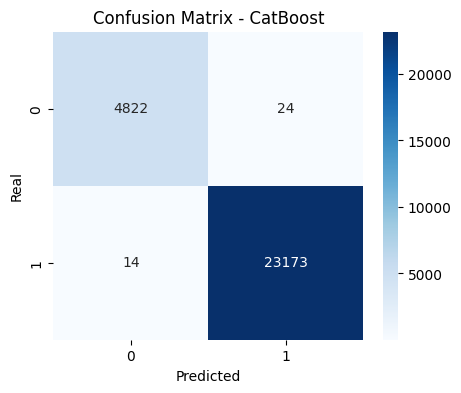


--- Analytics per Attack Type (CatBoost) ---


,Attack_Type,Total_Samples,Correct_Predictions,Detection_Rate (%)
5,Normal,4846,4822,99.50
8,Ransomware,2039,2032,99.66
10,Uploading,2052,2048,99.81
12,XSS,1924,1921,99.84
3,DDoS_TCP,2050,2050,100.00
0,Backdoor,1998,1998,100.00
2,DDoS_ICMP,2818,2818,100.00
1,DDoS_HTTP,2112,2112,100.00
7,Port_Scanning,1938,1938,100.00
6,Password,1996,1996,100.00


In [208]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=100, 
    random_state=42, 
    verbose=False
)
cat_model.fit(X_train, y_train)

y_pred_cat = cat_model.predict(X_test)
y_prob_cat = cat_model.predict_proba(X_test)[:, 1]

summary_df = evaluate_model(
    y_true=y_test, 
    y_pred=y_pred_cat, 
    y_prob=y_prob_cat, 
    model_name="CatBoost", 
    attack_types=Y_str_test, 
    tracking_df=summary_df
)

## 6. Comparison y Model Saving

In [209]:
display(summary_df.sort_values(by='Recall', ascending=False))

,Model,Accuracy,Precision,Recall,F1_Score,AUC
1,Random Forest,0.99893,0.998929,0.99893,0.998929,0.999839
6,LightGBM,0.998823,0.998822,0.998823,0.998822,0.999986
4,HistGradientBoosting,0.99868,0.99868,0.99868,0.998679,0.999986
2,Extra Trees,0.998644,0.998644,0.998644,0.998644,0.999771
7,CatBoost,0.998644,0.998644,0.998644,0.998644,0.99996
5,XGBoost,0.998537,0.998537,0.998537,0.998536,0.999987
3,Decision Tree,0.998074,0.998073,0.998074,0.998073,0.996306
0,Logistic Regression,0.906218,0.903376,0.906218,0.904459,0.967677


In [ ]:
%reload_ext autoreload
%autoreload 2

import joblib

model_path = config['binary_model_path'] / f"model_rf.pkl"
joblib.dump(rf_model, model_path)

model_path = config['binary_model_path'] / f"model_lgbm.pkl"
joblib.dump(lgbm_model, model_path)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


['/home/uo294319/ML-NIDS-IIoT/models/binary/edge_iiot/model_lgbm.pkl']